<a href="https://colab.research.google.com/github/pri265126-stack/delhi-uber-eda/blob/main/aws_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delhi Uber Ride Dataset — Exploratory Data Analysis (EDA)

### ML Domain Task

**Prepared by:** Priya Tiwari

## Objective

The goal of this project is to perform Exploratory Data Analysis (EDA) on a Delhi Uber ride dataset to understand booking patterns, identify inconsistencies in the data, clean missing values, visualize important trends, and derive meaningful business insights.

In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load the Dataset

In this step, we load the Delhi Uber ride dataset into a Pandas DataFrame and preview the first few records.

In [19]:
import pandas as pd

df = pd.read_csv("/content/delhi_uber_dataset aws")

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2025-09-23,21:25:15,UBR197645,Driver Cancelled,cust23444,Uber Auto,Lajpat Nagar,Noida Sector 62,2.2,-,NaN,Yes,Too far,NO,NaN,NaN,16.5,NaN,NaN,Credit Card
1,2025-10-13,16:36:45,UBR140756,Completed,CUST65862,Uber Go,Aerocity,Vasant Kunj,3.8,29.1,NaN,NO,NaN,NO,NaN,511.6,25.9,3.7,4.6,Unknown
2,11-03-2025,NaN,UBR152026,Completed,CUST72140,Moto,Faridabad,Greater Kailash,90.0,49.9,NaN,NO,NaN,NO,NaN,135.8,5.7,4.4,4.7,Debit Card
3,NaN,16:59:32,UBR109526,Incomplete,CUST67783,Uber Auto,Ghaziabad,Saket,8.4,23.3,NaN,NO,NaN,Yes,NaN,NaN,10.8,NaN,NaN,upi
4,2025-07-16,23:36:10,UBR170351,Completed,CUST24921,uber xl,Faridabad,Rohini,5.4,16.9,NaN,No,NaN,No,NaN,121.3,3.3,5.0,4.6,debit card


In [2]:
df.shape

(100000, 20)

In [3]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Reason for cancelling by Customer',
       'Cancelled Rides by Driver', 'Driver Cancellation Reason',
       'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Date                               95976 non-null  object
 1   Time                               96728 non-null  object
 2   Booking ID                         99702 non-null  object
 3   Booking Status                     98678 non-null  object
 4   Customer ID                        95074 non-null  object
 5   Vehicle Type                       95987 non-null  object
 6   Pickup Location                    96643 non-null  object
 7   Drop Location                      96594 non-null  object
 8   Avg VTAT                           93996 non-null  object
 9   Avg CTAT                           90680 non-null  object
 10  Reason for cancelling by Customer  12210 non-null  object
 11  Cancelled Rides by Driver          96703 non-null  object
 12  Dri

## Step 4: Summary Statistics

Generate summary statistics for numerical columns.

In [5]:
df.describe().T

,count,unique,top,freq
Date,95976,2193,2025-12-17,253
Time,96728,53092,Unknown,232
Booking ID,99702,98645,UBR190410,3
Booking Status,98678,18,Completed,51160
Customer ID,95074,50745,-,349
Vehicle Type,95987,22,Uber Go,23463
Pickup Location,96643,50,Greater Kailash,3386
Drop Location,96594,50,Rohini,3375
Avg VTAT,93996,246,-,1004
Avg CTAT,90680,561,60.0,8507


# Data Cleaning and Preprocessing

Before analysis, we check the dataset for missing values, duplicate records, and inconsistent entries.

In [6]:

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

missing_report[missing_report["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Incomplete Rides Reason,89602,89.60
Driver Cancellation Reason,89232,89.23
Reason for cancelling by Customer,87790,87.79
Driver Ratings,33512,33.51
Customer Rating,33215,33.22
Ride Distance,17974,17.97
Booking Value,16089,16.09
Avg CTAT,9320,9.32
Payment Method,7648,7.65
Avg VTAT,6004,6.00


## Step 2: Data Quality Report

Generate a quick report showing data type, missing values, missing percentage, and unique values for every feature.

In [7]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": ((df.isnull().sum() / len(df)) * 100).round(2),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
Date,object,4024,4.02,2193
Time,object,3272,3.27,53092
Booking ID,object,298,0.30,98645
Booking Status,object,1322,1.32,18
Customer ID,object,4926,4.93,50745
Vehicle Type,object,4013,4.01,22
Pickup Location,object,3357,3.36,50
Drop Location,object,3406,3.41,50
Avg VTAT,object,6004,6.00,246
Avg CTAT,object,9320,9.32,561


In [8]:
# Count duplicate rows
df.duplicated().sum()

np.int64(674)

In [9]:

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

## Step 4: Standardize Payment Method Values

Some payment methods are written in different formats (such as "UPI", "upi", and "Debit Card"). We standardize them into consistent categories.

In [10]:
df["Payment Method"].value_counts(dropna=False)

,count
Payment Method,
UPI,27975
Cash,13276
Credit Card,10671
upi,8399
Debit Card,7929
NaN,7606
Wallet,6762
Unknown,3236
debit card,2468


In [11]:
df["Payment Method"] = (
    df["Payment Method"]
    .str.strip()
    .str.title()
)

df["Payment Method"].value_counts()

,count
Payment Method,
Upi,36374
Cash,17367
Credit Card,12248
Debit Card,10397
Wallet,8730
Unknown,3236
Creditcard,1608
Not Available,917
-,843


In [12]:

df = df.drop_duplicates()

df.shape

(99326, 20)

## Step 7: Analyze Missing Values

Let's identify which columns still contain missing values after removing duplicates.

In [13]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": ((df.isnull().sum() / len(df)) * 100).round(2)
})

missing_report[missing_report["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Incomplete Rides Reason,89009,89.61
Driver Cancellation Reason,88635,89.24
Reason for cancelling by Customer,87186,87.78
Driver Ratings,33296,33.52
Customer Rating,33007,33.23
Ride Distance,17845,17.97
Booking Value,15987,16.10
Avg CTAT,9240,9.30
Payment Method,7606,7.66
Avg VTAT,5974,6.01


##  Handle Missing Values

Fill missing values based on the type of feature.

In [14]:

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

##  Verify Data Cleaning

In [15]:
df.isnull().sum().sum()

np.int64(0)

##  Save Cleaned Dataset

In [16]:
df.to_csv("delhi_uber_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Univariate Analysis

## Graph 1: Distribution of Booking Status

This visualization shows how many rides were successfully completed and how many were cancelled.

In [29]:

df["Booking Status"] = (
    df["Booking Status"]
    .str.strip()
    .str.lower()
    .replace({
        "completed": "Completed",
        "cancelled": "Cancelled",
        "customer cancelled": "Customer Cancelled",
        "driver cancelled": "Driver Cancelled",
        "no driver found": "No Driver Found"
    })
)

# Vehicle Type
df["Vehicle Type"] = (
    df["Vehicle Type"]
    .str.strip()
    .str.lower()
    .replace({
        "ubergo": "Uber Go",
        "go": "Uber Go",

        "uber auto": "Uber Auto",
        "uberauto": "Uber Auto",
        "auto": "Uber Auto",

        "uber premier": "Uber Premier",
        "premier": "Uber Premier",

        "uber xl": "Uber XL",
        "uberxl": "Uber XL",

        "bike": "Bike",

        "unknown": "Unknown",
        "not available": "Unknown"
    })
)

# Payment Method
df["Payment Method"] = (
    df["Payment Method"]
    .str.strip()
    .str.lower()
    .replace({
        "upi": "UPI",

        "cash": "Cash",

        "credit card": "Credit Card",
        "creditcard": "Credit Card",

        "debit card": "Debit Card",
        "debitcard": "Debit Card",

        "wallet": "Wallet",

        "unknown": "Unknown",
        "not available": "Unknown"
    })
)

print("Categorical columns cleaned successfully!")

Categorical columns cleaned successfully!


/tmp/ipykernel_644/4091171982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


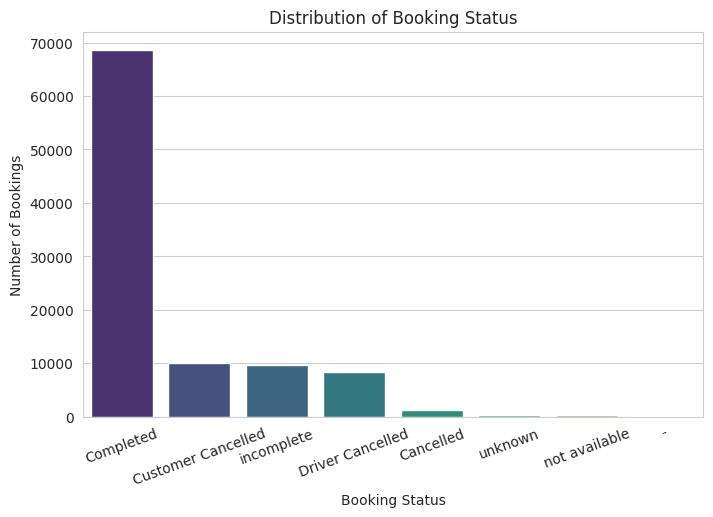

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Booking Status",
    order=df["Booking Status"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.show()

## Graph 2: Distribution of Vehicle Types

This graph shows the number of bookings for each Uber vehicle category.

/tmp/ipykernel_644/2272046425.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


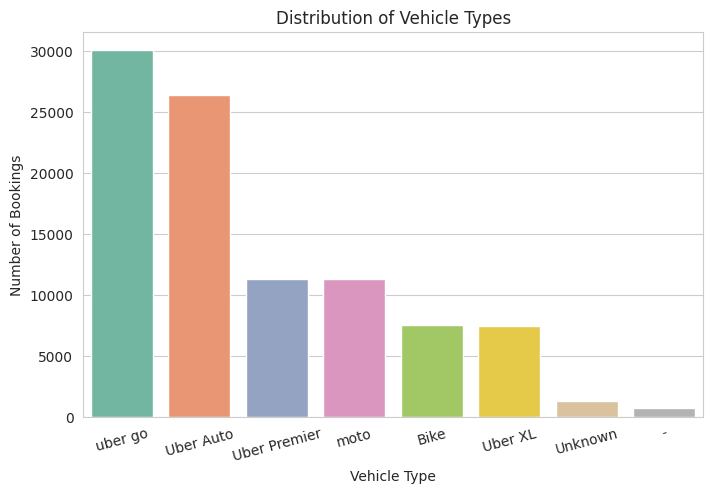

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Vehicle Type",
    order=df["Vehicle Type"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=15)

plt.show()

## Graph 3: Distribution of Payment Methods

This graph shows the most commonly used payment methods for Uber rides.

/tmp/ipykernel_644/3061258706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


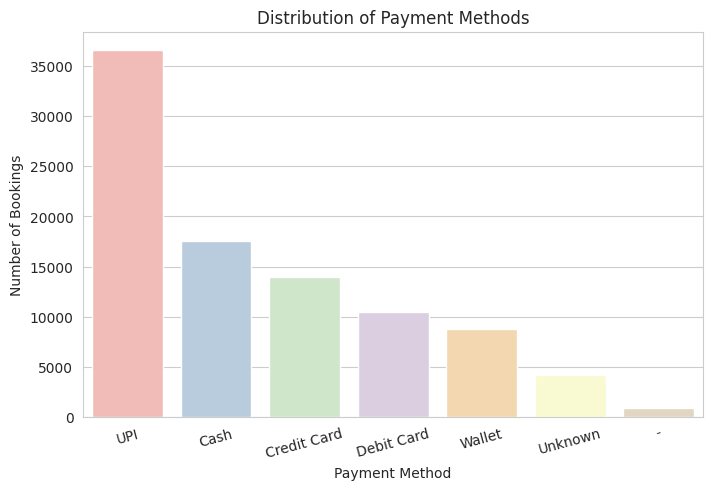

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment Method",
    order=df["Payment Method"].value_counts().index,
    palette="Pastel1"
)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=15)

plt.show()

## Graph 4: Distribution of Ride Distance

This histogram shows the distribution of ride distances in the dataset.

In [34]:
df["Ride Distance"].dtype

dtype('O')

In [35]:
# Convert Ride Distance to numeric
df["Ride Distance"] = pd.to_numeric(df["Ride Distance"], errors="coerce")

# Check data type again
df["Ride Distance"].dtype

dtype('float64')

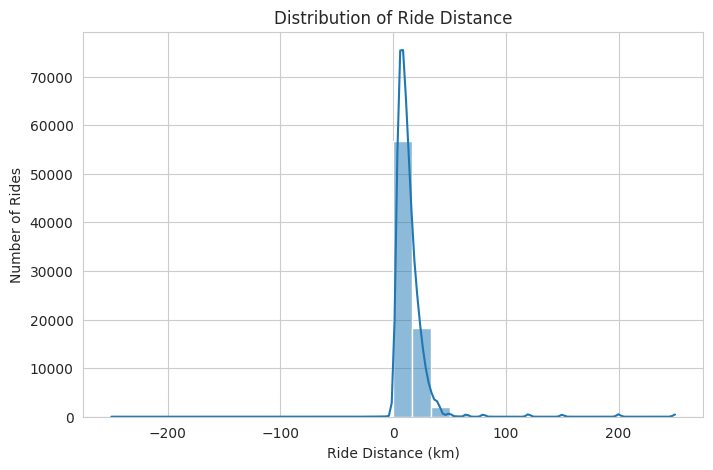

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Ride Distance",
    bins=30,
    kde=True
)

plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance (km)")
plt.ylabel("Number of Rides")

plt.show()

## Graph 5: Distribution of Booking Value

This histogram shows the distribution of booking values across all Uber rides.

In [37]:

df["Booking Value"] = pd.to_numeric(df["Booking Value"], errors="coerce")

df["Booking Value"].dtype

dtype('float64')

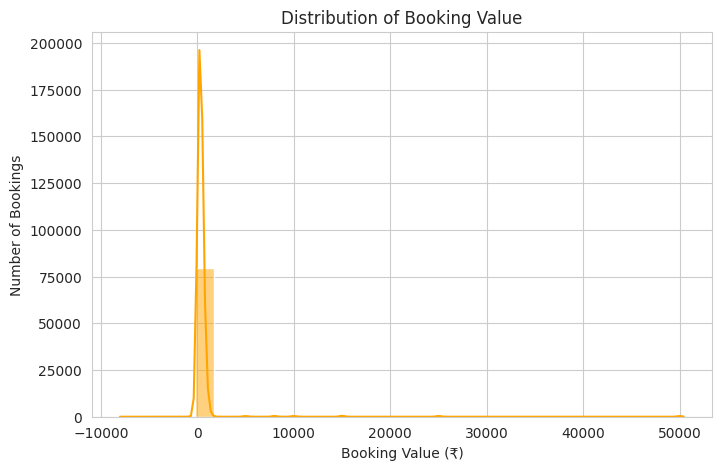

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Booking Value",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Booking Value")
plt.xlabel("Booking Value (₹)")
plt.ylabel("Number of Bookings")

plt.show()

## Graph 6: Distribution of Customer Ratings

This graph shows how customer ratings are distributed across Uber rides.

In [39]:

df["Customer Rating"] = pd.to_numeric(df["Customer Rating"], errors="coerce")


df["Customer Rating"].dtype

dtype('float64')

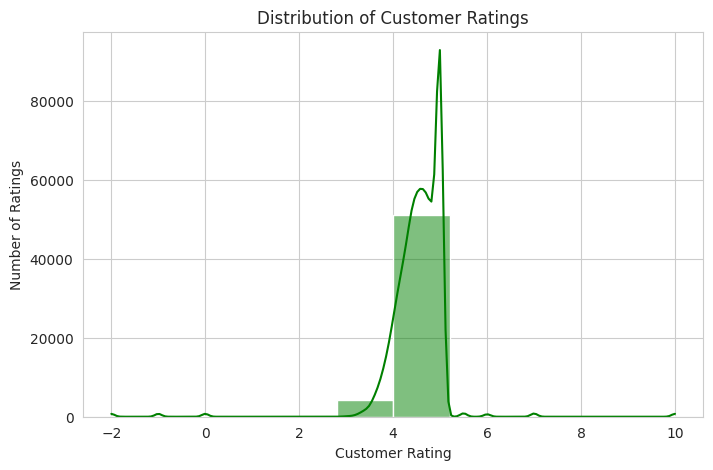

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Customer Rating",
    bins=10,
    kde=True,
    color="green"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Ratings")

plt.show()

# Bivariate Analysis

## Graph 7: Booking Value vs Ride Distance

This scatter plot shows the relationship between ride distance and booking value.

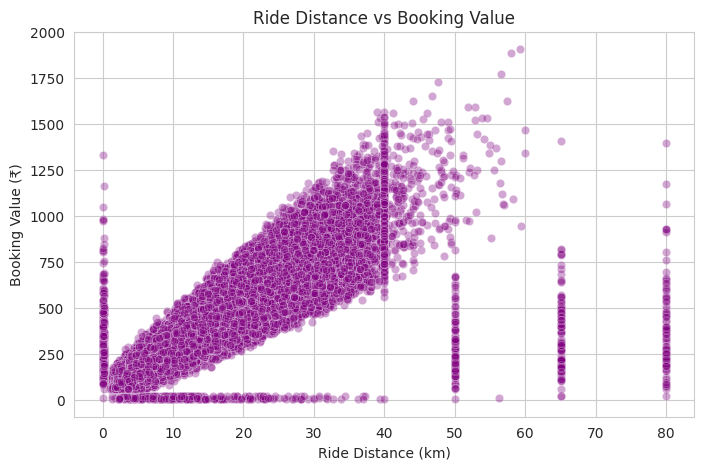

In [45]:
# Better visualization (remove capped fare values only for graph)
df_scatter = df[
    (df["Ride Distance"] >= 0) &
    (df["Ride Distance"] <= 80) &
    (df["Booking Value"] > 0) &
    (df["Booking Value"] < 5000)   # 5000 ko bhi remove
]

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_scatter,
    x="Ride Distance",
    y="Booking Value",
    alpha=0.35,
    color="purple"
)

plt.title("Ride Distance vs Booking Value")
plt.xlabel("Ride Distance (km)")
plt.ylabel("Booking Value (₹)")
plt.show()

## Graph 8: Average Booking Value by Vehicle Type

This bar chart compares the average booking value across different vehicle categories.

/tmp/ipykernel_644/2020263344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


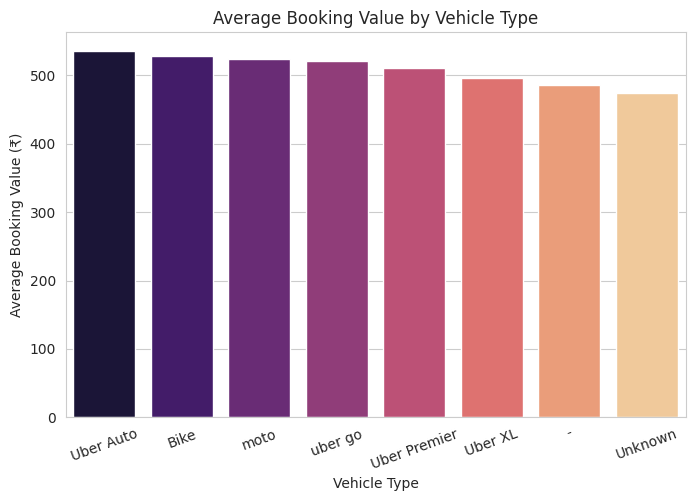

In [42]:
plt.figure(figsize=(8,5))

avg_booking = df.groupby("Vehicle Type")["Booking Value"].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_booking.index,
    y=avg_booking.values,
    palette="magma"
)

plt.title("Average Booking Value by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Booking Value (₹)")
plt.xticks(rotation=20)

plt.show()

## Graph 9: Booking Value Distribution by Vehicle Type

This box plot compares the booking value distribution across different vehicle categories and helps identify outliers.

/tmp/ipykernel_644/1051667476.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


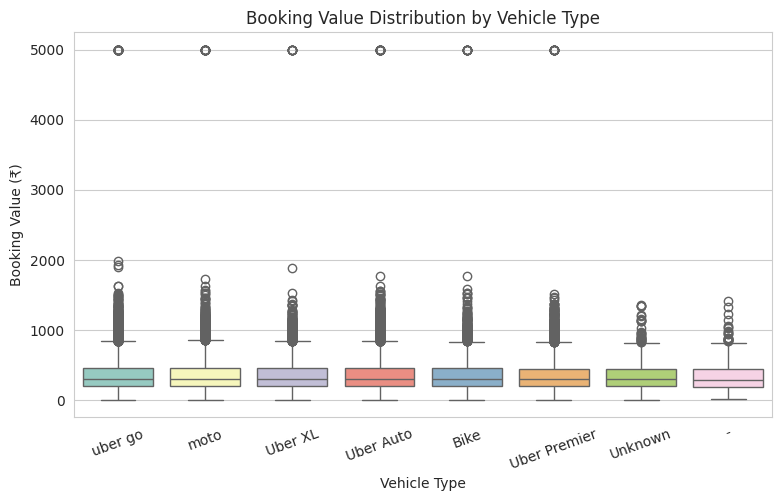

In [46]:
# Filter unrealistic values only for visualization
df_box = df[(df["Booking Value"] >= 0) & (df["Booking Value"] <= 5000)]

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_box,
    x="Vehicle Type",
    y="Booking Value",
    palette="Set3"
)

plt.title("Booking Value Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Booking Value (₹)")
plt.xticks(rotation=20)

plt.show()

## Graph 10: Average Customer Rating by Vehicle Type

This bar chart compares the average customer rating for each vehicle category.

/tmp/ipykernel_644/3608795052.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


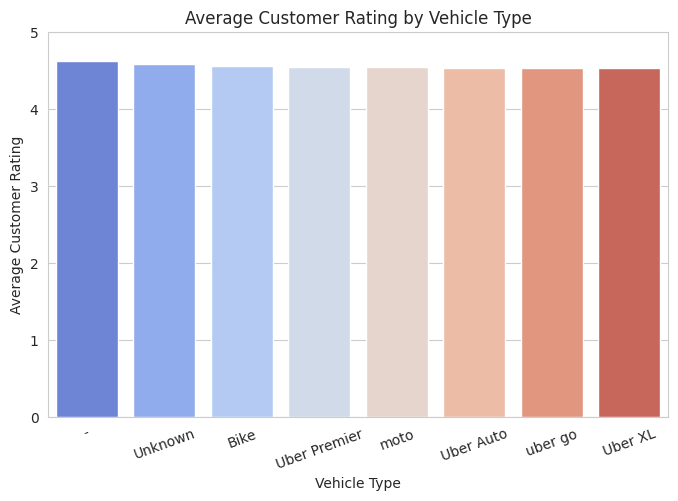

In [47]:
plt.figure(figsize=(8,5))

avg_rating = (
    df.groupby("Vehicle Type")["Customer Rating"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    palette="coolwarm"
)

plt.title("Average Customer Rating by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Customer Rating")
plt.xticks(rotation=20)

plt.ylim(0,5)

plt.show()